Loading research-optimized data...
Stock: SPY
Features: 30
Samples: 2851
Train: 1981, Val: 425, Test: 425
Train class distribution: [ 271 1278  432]

Random Forest baseline:
RF accuracy: 0.605
Original class distribution: [ 271 1278  432]
Device: cpu
Class weights: tensor([2.4367, 0.5167, 1.5285])
Model parameters: 3,123

Starting training...
Epoch   1: Loss=0.4691/0.5831, Acc=0.433/0.421
Epoch  11: Loss=0.4524/0.5639, Acc=0.448/0.426
Epoch  21: Loss=0.4413/0.5531, Acc=0.473/0.464
Epoch  31: Loss=0.4325/0.5486, Acc=0.461/0.449
Epoch  41: Loss=0.4243/0.5467, Acc=0.490/0.442
Epoch  51: Loss=0.4213/0.5451, Acc=0.512/0.424
Epoch  61: Loss=0.4212/0.5440, Acc=0.505/0.407
Epoch  71: Loss=0.4166/0.5431, Acc=0.519/0.405
Epoch  81: Loss=0.4191/0.5416, Acc=0.511/0.402
Epoch  91: Loss=0.4177/0.5413, Acc=0.533/0.402
Epoch 101: Loss=0.4166/0.5407, Acc=0.538/0.398
Epoch 111: Loss=0.4191/0.5406, Acc=0.547/0.400
Epoch 121: Loss=0.4127/0.5395, Acc=0.543/0.372
Epoch 131: Loss=0.4109/0.5388, Acc=0.548/0.3

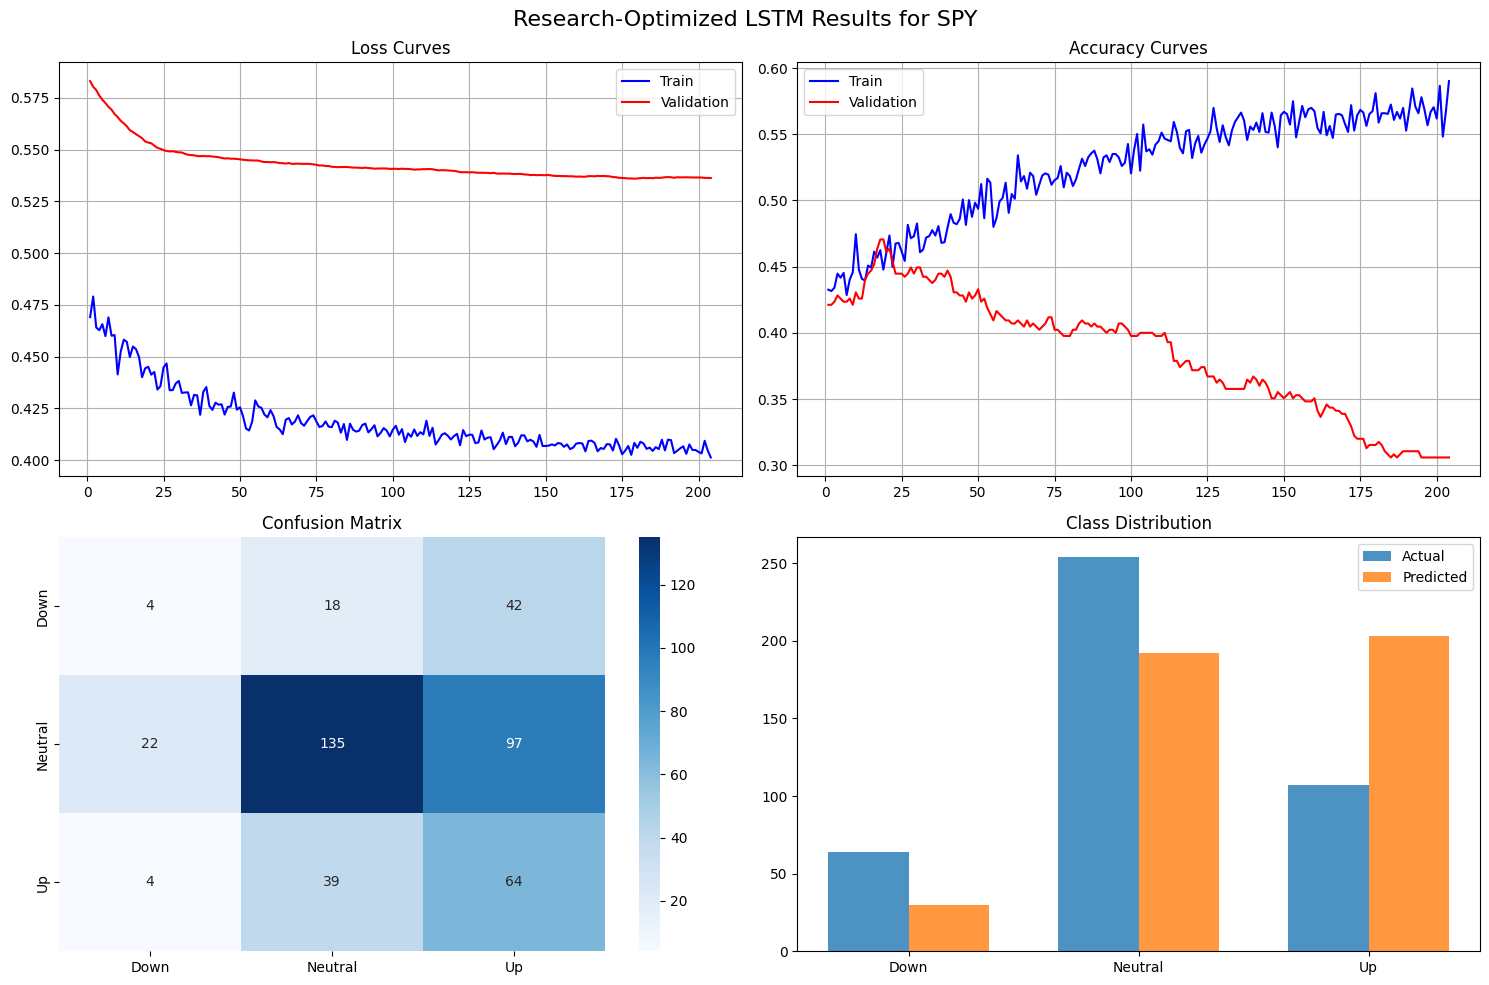

In [53]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        
        # Handle tensor alpha (per-class weights)
        if isinstance(self.alpha, torch.Tensor):
            alpha_t = self.alpha[targets]
        else:
            alpha_t = self.alpha
            
        focal_loss = alpha_t * (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

def calculate_class_weights(y_train):
    """Calculate class weights for imbalanced dataset"""
    counts = np.bincount(y_train.astype(int), minlength=3)
    weights = len(y_train) / (len(counts) * counts)
    return torch.FloatTensor(weights)

# class ResearchOptimizedBiLSTM(nn.Module):
#     """LSTM optimized based on research findings"""
#     def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.3):
#         super(ResearchOptimizedBiLSTM, self).__init__()
        
#         self.lstm = nn.LSTM(
#             input_size=input_size,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             batch_first=True,
#             dropout=dropout if num_layers > 1 else 0,
#             bidirectional=True
#         )
        
#         self.dropout = nn.Dropout(dropout)
#         self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        
#         # Feature extraction layers
#         self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
#         self.fc3 = nn.Linear(hidden_size // 2, 3)
        
#         self.relu = nn.ReLU()
        
#         # Initialize weights
#         self._init_weights()
    
#     def _init_weights(self):
#         for layer in [self.fc1, self.fc2, self.fc3]:
#             nn.init.xavier_uniform_(layer.weight)
#             nn.init.constant_(layer.bias, 0.0)
    
#     def forward(self, x):
#         lstm_out, _ = self.lstm(x)
#         out = lstm_out[:, -1, :]  # Last timestep
        
#         # Batch normalization
#         out = self.batch_norm(out)
#         out = self.dropout(out)
        
#         # Feed forward layers
#         out = self.fc1(out)
#         out = self.relu(out)
#         out = self.dropout(out)
        
#         out = self.fc2(out)
#         out = self.relu(out)
#         out = self.dropout(out)
        
#         out = self.fc3(out)
#         return out

class SimplerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 3)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

class StockDataset(Dataset):
    def __init__(self, sequences, targets):
        self.sequences = sequences
        self.targets = targets.astype(int)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        x = torch.FloatTensor(self.sequences[idx])
        y = torch.tensor(self.targets[idx], dtype=torch.long)
        return x, y

def prepare_stock_data(df, feature_cols, seq_len=15, train_split=0.7, val_split=0.15):
    """Prepare sequential data for LSTM training"""
    stock_data = df.sort_values('Date').reset_index(drop=True)
    
    all_sequences = []
    all_targets = []
    
    if len(stock_data) < seq_len + 1:
        raise ValueError("Not enough data to create sequences.")
        
    X_vals = stock_data[feature_cols].values
    y_vals = stock_data['Target'].values

    for i in range(seq_len, len(X_vals)):
        all_sequences.append(X_vals[i-seq_len:i])
        all_targets.append(y_vals[i])
    
    X_seq = np.array(all_sequences)
    y_seq = np.array(all_targets)
    
    # Split data chronologically
    train_idx = int(len(X_seq) * train_split)
    val_idx = int(len(X_seq) * (train_split + val_split))
    
    X_train, y_train = X_seq[:train_idx], y_seq[:train_idx]
    X_val, y_val = X_seq[train_idx:val_idx], y_seq[train_idx:val_idx]
    X_test, y_test = X_seq[val_idx:], y_seq[val_idx:]
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

def train_research_optimized_model():
    """Train LSTM with research-optimized features"""
    
    print("Loading research-optimized data...")
    df_full = pd.read_csv("../data/processed/stock_data_research_optimized.csv")
    
    # Filter for specific stock
    STOCK_TO_USE = "SPY"  # S&P 500 ETF
    df_filtered = df_full[df_full['Ticker'] == STOCK_TO_USE].copy()
    
    # Get feature columns (all lag features)
    FEATURES_TO_USE = [col for col in df_filtered.columns if '_lag_' in col]
    
    print(f"Stock: {STOCK_TO_USE}")
    print(f"Features: {len(FEATURES_TO_USE)}")
    print(f"Samples: {len(df_filtered)}")
    
    # Create sequences
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_stock_data(
        df_filtered,
        feature_cols=FEATURES_TO_USE,
        seq_len=20  # Research suggests 21-60 days optimal
    )
    
    print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
    print(f"Train class distribution: {np.bincount(y_train, minlength=3)}")
    
    # Scale data
    scaler = StandardScaler()
    num_samples, seq_len, num_features = X_train.shape
    X_train_reshaped = X_train.reshape(-1, num_features)
    scaler.fit(X_train_reshaped)
    
    X_train = scaler.transform(X_train.reshape(-1, num_features)).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, num_features)).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, num_features)).reshape(X_test.shape)

    print("\nRandom Forest baseline:")
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced')
    rf.fit(X_train.reshape(len(X_train), -1), y_train)
    rf_accuracy = rf.score(X_test.reshape(len(X_test), -1), y_test)
    print(f"RF accuracy: {rf_accuracy:.3f}")

    print("Original class distribution:", np.bincount(y_train))
    # # Handle class imbalance with SMOTE
    # # Reshape for SMOTE (needs 2D)
    # X_train_2d = X_train.reshape(len(X_train), -1)

    # # Apply SMOTE
    # smote = SMOTE(random_state=42)
    # X_train_balanced, y_train_balanced = smote.fit_resample(X_train_2d, y_train)

    # # Reshape back to 3D for LSTM
    # X_train = X_train_balanced.reshape(-1, seq_len, num_features)
    # y_train = y_train_balanced

    # print("Balanced class distribution:", np.bincount(y_train))
    
    # Setup model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")
    
    # Calculate class weights
    class_weights = calculate_class_weights(y_train)
    print(f"Class weights: {class_weights}")
    
    # Create datasets
    train_dataset = StockDataset(X_train, y_train)
    val_dataset = StockDataset(X_val, y_val)
    test_dataset = StockDataset(X_test, y_test)
    
    # Create model
    model = SimplerLSTM(
        input_size=X_train.shape[2],
        hidden_size=16,
        dropout=0.9
    ).to(device)

    criterion = FocalLoss(alpha=torch.tensor([1.7, 0.4, 1.0]), gamma=1.5)
    # criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-1)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=50)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # def get_weighted_sampler(targets):
    #     class_counts = np.bincount(targets)
    #     weights = 1.0 / class_counts[targets]
    #     return WeightedRandomSampler(weights, len(weights))

    # Training loop
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 25
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    
    print("\nStarting training...")
    for epoch in range(300):
        # Training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            
            # L2 regularization
            l2_reg = 0.001 * sum(p.pow(2.0).sum() for p in model.parameters())
            total_loss = loss + l2_reg
            
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)
            train_correct += (predictions == batch_y).sum().item()
            train_total += batch_y.size(0)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = criterion(logits, batch_y)
                val_loss += loss.item()
                
                predictions = torch.argmax(logits, dim=1)
                val_correct += (predictions == batch_y).sum().item()
                val_total += batch_y.size(0)
        
        # Calculate metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        if epoch % 10 == 0:
            print(f"Epoch {epoch+1:3d}: Loss={avg_train_loss:.4f}/{avg_val_loss:.4f}, "
                  f"Acc={train_acc:.3f}/{val_acc:.3f}")
        
        scheduler.step(avg_val_loss)
        
        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_research_model.pth')
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Evaluation
    print("\nEvaluating on test set...")
    model.load_state_dict(torch.load('best_research_model.pth'))
    model.eval()
    
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    all_predictions, all_targets, all_probs = [], [], []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.softmax(logits, dim=1)
            # Adjust thresholds: make neutral harder to predict
            # predictions = torch.zeros(probs.size(0), dtype=torch.long)
            # predictions[probs[:, 0] > 0.4] = 0  # Down
            # predictions[probs[:, 2] > 0.4] = 2  # Up  
            # predictions[(probs[:, 0] <= 0.4) & (probs[:, 2] <= 0.4)] = 1  # Neutral (default)
            predictions = torch.argmax(logits, dim=1)
            
            all_predictions.extend(predictions.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Results
    accuracy = accuracy_score(all_targets, all_predictions)
    print(f"\nTest Accuracy: {accuracy:.3f}")
    
    print("\nClassification Report:")
    print(classification_report(all_targets, all_predictions,
                               target_names=['Down', 'Neutral', 'Up'], 
                               labels=[0, 1, 2]))
    
    # Confusion Matrix
    cm = confusion_matrix(all_targets, all_predictions, labels=[0, 1, 2])
    print(f"\nConfusion Matrix:")
    print("Predicted:  Down  Neutral  Up")
    for i, actual in enumerate(['Down', 'Neutral', 'Up']):
        print(f"Actual {actual:>7}: {cm[i]}")
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Research-Optimized LSTM Results for {STOCK_TO_USE}', fontsize=16)
    
    # Loss curves
    epochs = range(1, len(train_losses) + 1)
    axes[0,0].plot(epochs, train_losses, 'b-', label='Train')
    axes[0,0].plot(epochs, val_losses, 'r-', label='Validation')
    axes[0,0].set_title('Loss Curves')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Accuracy curves
    axes[0,1].plot(epochs, train_accs, 'b-', label='Train')
    axes[0,1].plot(epochs, val_accs, 'r-', label='Validation')
    axes[0,1].set_title('Accuracy Curves')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[1,0], 
               xticklabels=['Down', 'Neutral', 'Up'], 
               yticklabels=['Down', 'Neutral', 'Up'],
               cmap='Blues')
    axes[1,0].set_title('Confusion Matrix')

    # Class distribution comparisons
    x = np.arange(3)
    actual_counts = np.bincount(all_targets, minlength=3)
    predicted_counts = np.bincount(all_predictions, minlength=3)
    
    width = 0.35
    axes[1,1].bar(x - width/2, actual_counts, width, label='Actual', alpha=0.8)
    axes[1,1].bar(x + width/2, predicted_counts, width, label='Predicted', alpha=0.8)
    axes[1,1].set_title('Class Distribution')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(['Down', 'Neutral', 'Up'])
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.savefig('research_optimized_results.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return model, accuracy

if __name__ == "__main__":
    model, accuracy = train_research_optimized_model()